In [1]:
import numpy as np
import pandas as pd

## 🔵 Task 7: Netflix Dataset Analysis

In [2]:
df = pd.read_csv('NetFlix.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [25]:
full_genres = df['genres'].value_counts()
full_genres

genres
Documentaries                                                                      334
Stand-Up Comedy                                                                    321
Dramas, International Movies                                                       320
Comedies, Dramas, International Movies                                             243
Dramas, Independent Movies, International Movies                                   215
                                                                                  ... 
Kids' TV, Reality TV, Science & Nature TV                                            1
International TV Shows, Spanish-Language TV Shows, Stand-Up Comedy & Talk Shows      1
Sci-Fi & Fantasy                                                                     1
International TV Shows, TV Action & Adventure, TV Horror                             1
Stand-Up Comedy & Talk Shows, TV Mysteries, TV Sci-Fi & Fantasy                      1
Name: count, Length: 492, dtype: int

In [34]:
counter = {}
for genres, count in df['genres'].value_counts().items():
    for genre in genres.split(","):
        genre = genre.strip()
        counter[genre] = counter.get(genre, 0) + count

most_popular_genres = pd.Series(counter).sort_values(ascending=False)
most_popular_genres.head()
    

International Movies      2437
Dramas                    2106
Comedies                  1471
International TV Shows    1199
Documentaries              786
dtype: int64

In [33]:
most_popular_genre = (
    df["genres"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)
most_popular_genre.head()

genres
International Movies      2437
Dramas                    2106
Comedies                  1471
International TV Shows    1199
Documentaries              786
Name: count, dtype: int64

In [46]:
movie_count = len(df[df['type'] == 'Movie'])
show_count = len(df[df['type'] == 'TV Show'])
movie_count, show_count

(5377, 2410)

In [51]:
df.groupby('country').country.count()

country
Argentina                                              50
Argentina, Brazil, France, Poland, Germany, Denmark     1
Argentina, Chile                                        1
Argentina, Chile, Peru                                  1
Argentina, France                                       1
                                                       ..
Venezuela                                               1
Venezuela, Colombia                                     1
Vietnam                                                 5
West Germany                                            1
Zimbabwe                                                1
Name: country, Length: 681, dtype: int64

In [59]:
top_countries = (
    df['country'].str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)

top_countries

country
United States     3297
India              990
United Kingdom     723
Canada             412
France             349
                  ... 
Mongolia             1
Uganda               1
East Germany         1
Montenegro           1
Syria                1
Name: count, Length: 118, dtype: int64

In [61]:
year_trend = df["release_year"].value_counts().sort_index()
year_trend

release_year
1925       1
1942       2
1943       3
1944       3
1945       3
        ... 
2017    1012
2018    1121
2019     996
2020     868
2021      31
Name: count, Length: 73, dtype: int64

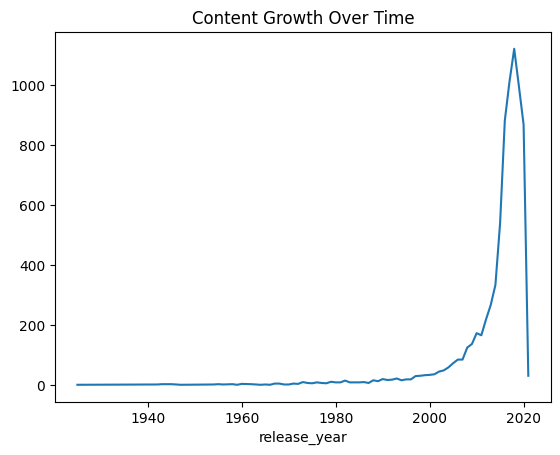

In [62]:
import matplotlib.pyplot as plt

year_trend.plot()
plt.title("Content Growth Over Time")
plt.show()